In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")

In [ ]:
print(customers.columns)

In [ ]:
customers.info

In [ ]:
customers.describe(include='all')

In [ ]:
print(customers.isnull().sum())

In [ ]:
print(customers.duplicated().sum())

In [ ]:
print(customers.dtypes)

In [ ]:
for col in customers.columns:
    print(col)
    print(customers[col].nunique())
    print()

In [ ]:
orders['order_purchase_timestamp']=pd.to_datetime(
    orders['order_purchase_timestamp'])

In [ ]:
df = customers.merge(
    orders,
    on='customer_id'
)

In [ ]:
plt.figure(figsize=(12,6))

customers['customer_state'].value_counts().plot(kind='bar')

plt.title("Customers by State")
plt.xlabel("State")
plt.ylabel("Customers")
plt.xticks(rotation=45)

plt.show()

In [ ]:
customers['customer_state'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title("Top 10 Customer States")
plt.ylabel("")
plt.show()

In [ ]:
print(orders.columns)

In [ ]:
orders.info

In [ ]:
orders.describe(include='all')

In [ ]:
print(orders.isnull().sum())

In [ ]:
print(orders.duplicated().sum())

In [ ]:
print(orders.dtypes)

In [ ]:
for col in orders.columns:
    print(col)
    print(orders[col].nunique())

In [ ]:
orders['order_approved_at']=pd.to_datetime(
    orders['order_approved_at'])


In [ ]:
df = df.merge(
    order_items,
    on='order_id'
)

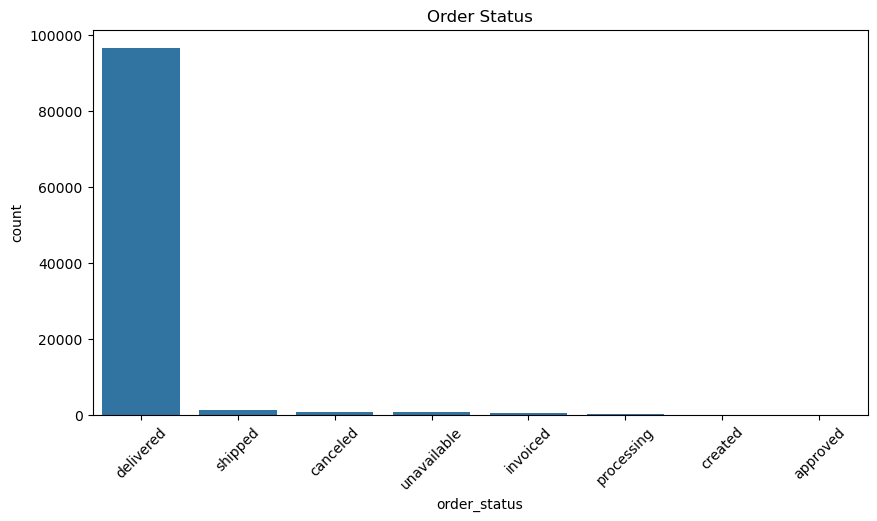

In [46]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='order_status',
    data=orders,
    order=orders['order_status'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Order Status")

plt.show()

In [ ]:
orders['Month']=orders['order_purchase_timestamp'].dt.to_period('M')

monthly=orders.groupby('Month').size()

plt.figure(figsize=(14,5))

monthly.plot()

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.show()

In [ ]:
print(products.columns)

In [ ]:
products.info()

In [ ]:
products.describe(include='all')

In [ ]:
print(products.isnull().sum())

In [ ]:
print(products.dtypes)

In [ ]:
for col in products.columns:
    print(col)
    print(products[col].nunique())

In [ ]:
orders['order_delivered_carrier_date']=pd.to_datetime(
    orders['order_delivered_carrier_date'])

In [ ]:

df = df.merge(
    products,
    on='product_id'
)

In [ ]:
plt.figure(figsize=(12,6))

products['product_category_name'].value_counts().head(10).plot(kind='bar')

plt.title("Top Product Categories")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(products['product_weight_g'].dropna(), bins=30)

plt.title("Product Weight Distribution")

plt.xlabel("Weight")

plt.ylabel("Frequency")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=products['product_weight_g'])

plt.title("Product Weight Boxplot")

plt.show()

In [ ]:
print(reviews.columns)

In [36]:
reviews.info

<bound method DataFrame.info of                               review_id                          order_id  \
0      7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1      80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2      228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3      e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4      f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   
...                                 ...                               ...   
99219  574ed12dd733e5fa530cfd4bbf39d7c9  2a8c23fee101d4d5662fa670396eb8da   
99220  f3897127253a9592a73be9bdfdf4ed7a  22ec9f0669f784db00fa86d035cf8602   
99221  b3de70c89b1510c4cd3d0649fd302472  55d4004744368f5571d1f590031933e4   
99222  1adeb9d84d72fe4e337617733eb85149  7725825d039fc1f0ceb7635e3f7d9206   
99223  efe49f1d6f951dd88b51e6ccd4cc548f  90531360ecb1eec2a1fbb265a0db0508   

       review_score review_comment_title  \

In [37]:
reviews.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [38]:
print(reviews.isnull().sum())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [39]:
print(reviews.duplicated().sum())

0


In [40]:

print(reviews.dtypes)

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


In [41]:
for col in reviews.columns:
    print(col)
    print(reviews[col].nunique())

review_id
98410
order_id
98673
review_score
5
review_comment_title
4527
review_comment_message
36159
review_creation_date
636
review_answer_timestamp
98248


In [42]:
orders['order_delivered_customer_date']=pd.to_datetime(
    orders['order_delivered_customer_date'])

In [43]:
df = df.merge(
    reviews,
    on='order_id'
)

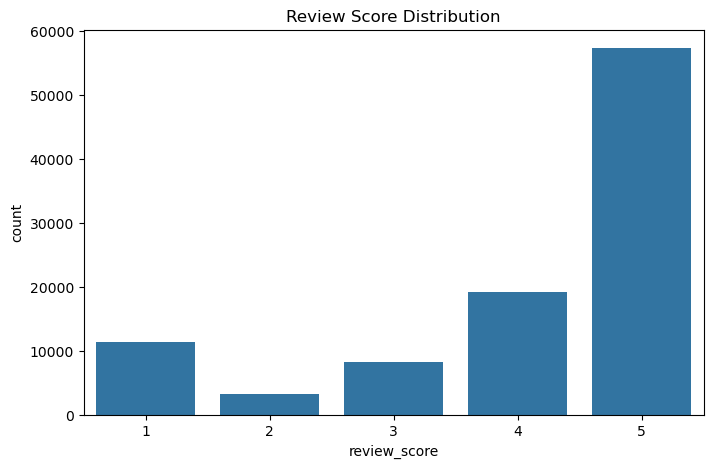

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(x='review_score', data=reviews)

plt.title("Review Score Distribution")

plt.show()

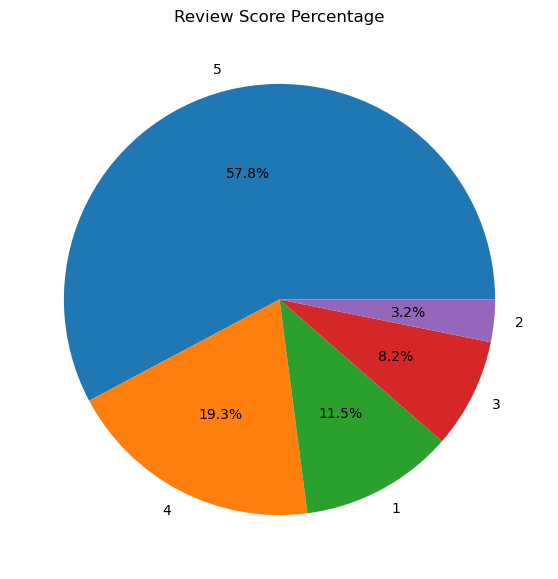

In [45]:
reviews['review_score'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Review Score Percentage")

plt.ylabel("")

plt.show()

In [47]:
print(order_items.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')


In [48]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [49]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [50]:
print(order_items.isnull().sum())

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [51]:
print(order_items.duplicated().sum())

0


In [52]:

print(order_items.dtypes)

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


In [53]:
for col in order_items.columns:
    print(col)
    print(order_items[col].nunique())

order_id
98666
order_item_id
21
product_id
32951
seller_id
3095
shipping_limit_date
93318
price
5968
freight_value
6999


In [54]:
orders['order_estimated_delivery_date']=pd.to_datetime(
    orders['order_estimated_delivery_date'])

In [55]:
df = df.merge(
    order_items,
    on='order_id'
)

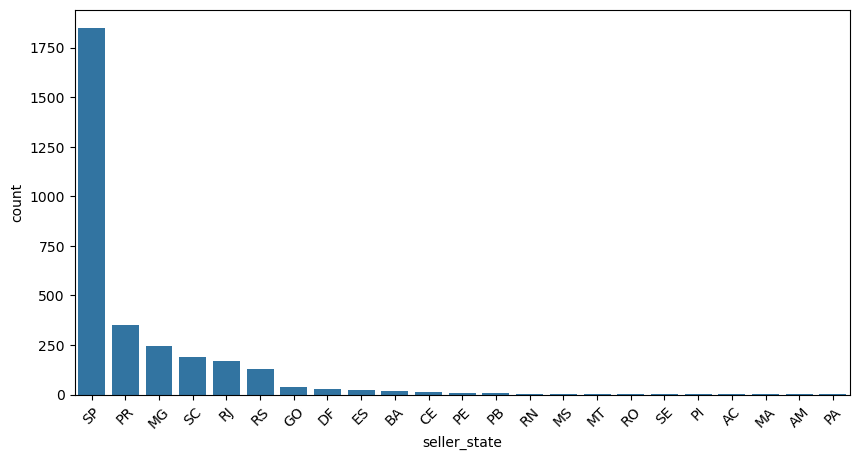

In [56]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='seller_state',
    data=sellers,
    order=sellers['seller_state'].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

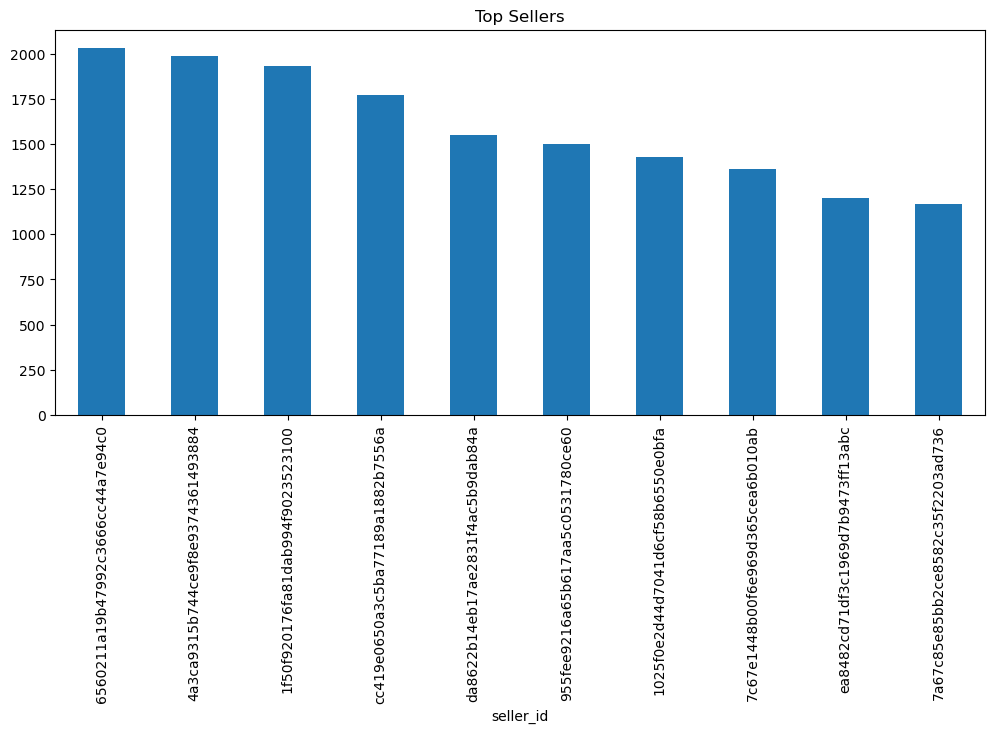

In [57]:
top=order_items['seller_id'].value_counts().head(10)

plt.figure(figsize=(12,5))

top.plot(kind='bar')

plt.title("Top Sellers")

plt.show()

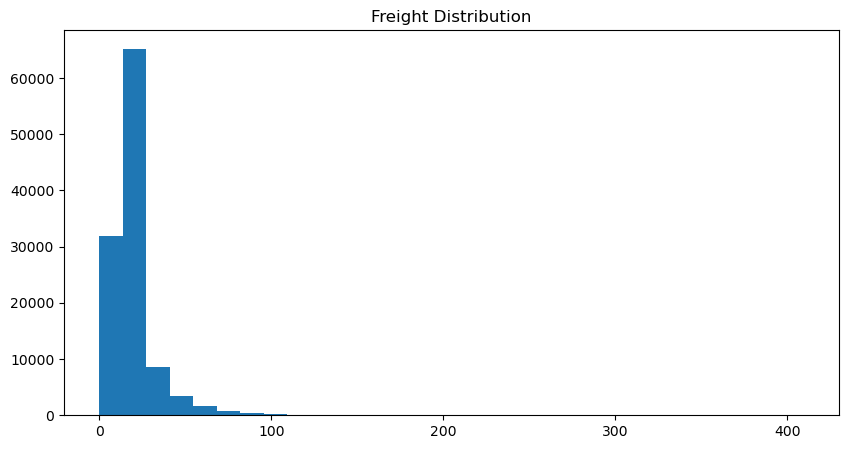

In [58]:
plt.figure(figsize=(10,5))

plt.hist(order_items['freight_value'], bins=30)

plt.title("Freight Distribution")

plt.show()

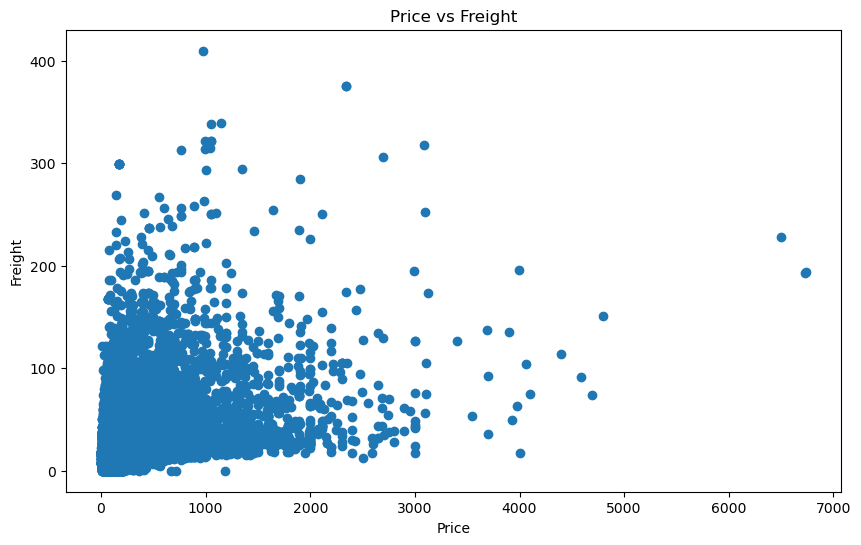

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(
    order_items['price'],
    order_items['freight_value']
)

plt.xlabel("Price")

plt.ylabel("Freight")

plt.title("Price vs Freight")

plt.show()

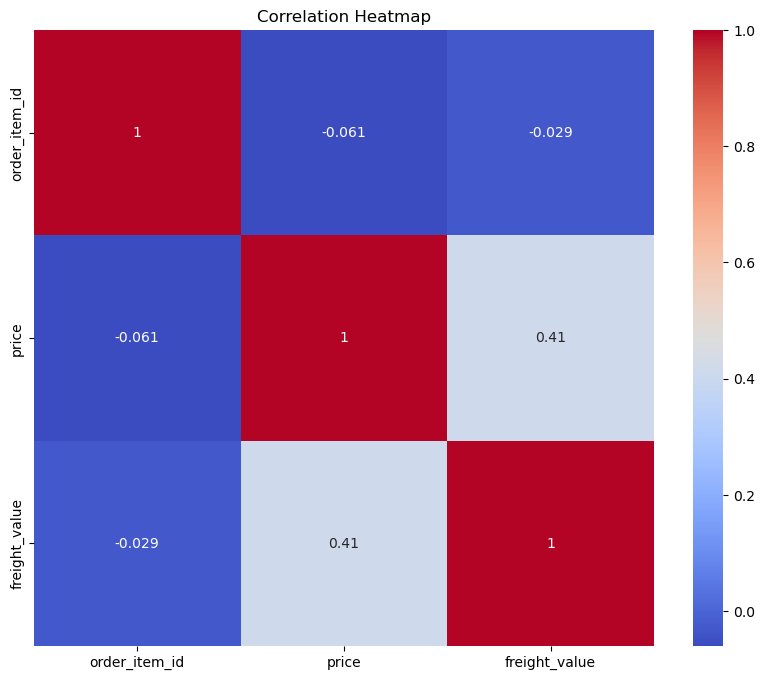

In [60]:
numeric=order_items.select_dtypes(include='number')

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

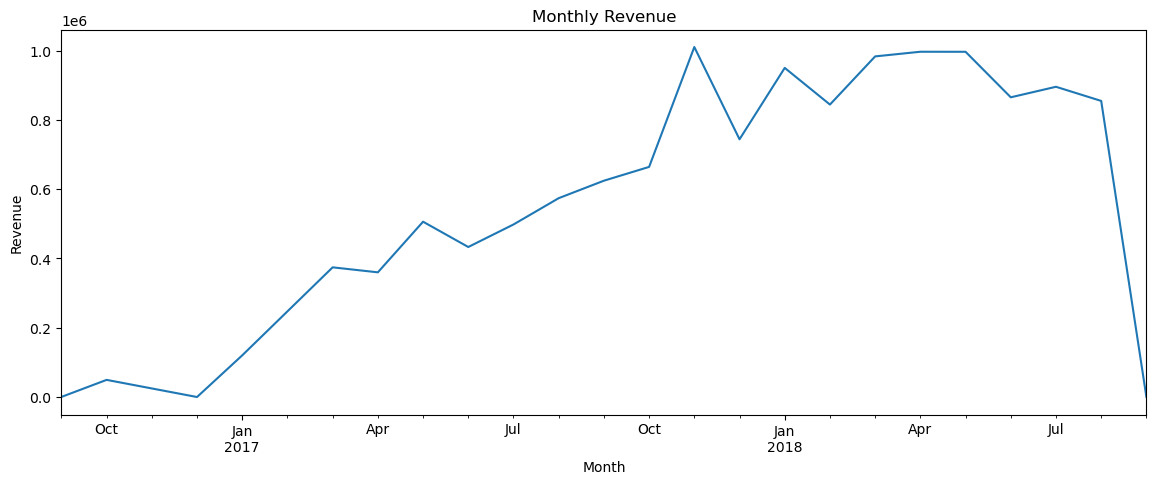

In [61]:
sales=orders.merge(order_items,on='order_id')

sales['Month']=sales['order_purchase_timestamp'].dt.to_period('M')

monthly_sales=sales.groupby('Month')['price'].sum()

plt.figure(figsize=(14,5))

monthly_sales.plot()

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()